In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm

# ----------------------------
# Physical / LISA constants
# ----------------------------
C_LIGHT = 299_792_458.0            # m/s
L_ARM   = 2.5e9                    # m (2.5 million km)
F_STAR  = C_LIGHT / (2.0*np.pi*L_ARM)  # f_* = c/(2πL), Eq. (4.13)

# H0/h = 100 km/s/Mpc in SI (s^-1)
MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M

# SciRD-like noise amplitude coefficients used in Appendix B
P_OMS_PM = 15.0   # P = 15
A_ACC_FM = 3.0    # A = 3


/var/folders/l6/yw7hsmzx1czfjt3n32sfq_w00000gn/T/ipykernel_22280/119487080.py:104: RuntimeWarning: overflow encountered in scalar power
  return dos * (x**2 * ex) / (denom**2)
/var/folders/l6/yw7hsmzx1czfjt3n32sfq_w00000gn/T/ipykernel_22280/119487080.py:104: RuntimeWarning: overflow encountered in scalar multiply
  return dos * (x**2 * ex) / (denom**2)
/var/folders/l6/yw7hsmzx1czfjt3n32sfq_w00000gn/T/ipykernel_22280/119487080.py:104: RuntimeWarning: invalid value encountered in scalar divide
  return dos * (x**2 * ex) / (denom**2)
/var/folders/l6/yw7hsmzx1czfjt3n32sfq_w00000gn/T/ipykernel_22280/119487080.py:117: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(
/var/folders/l6/yw7hsmzx1czfjt3n32sfq_w00000gn/T/ipykernel_22280/119487080.py:67: RuntimeWarning: overflow encountered in scalar power
  return R * (x**2 * ex) / (denom**2)
/var/folders/l6/yw7

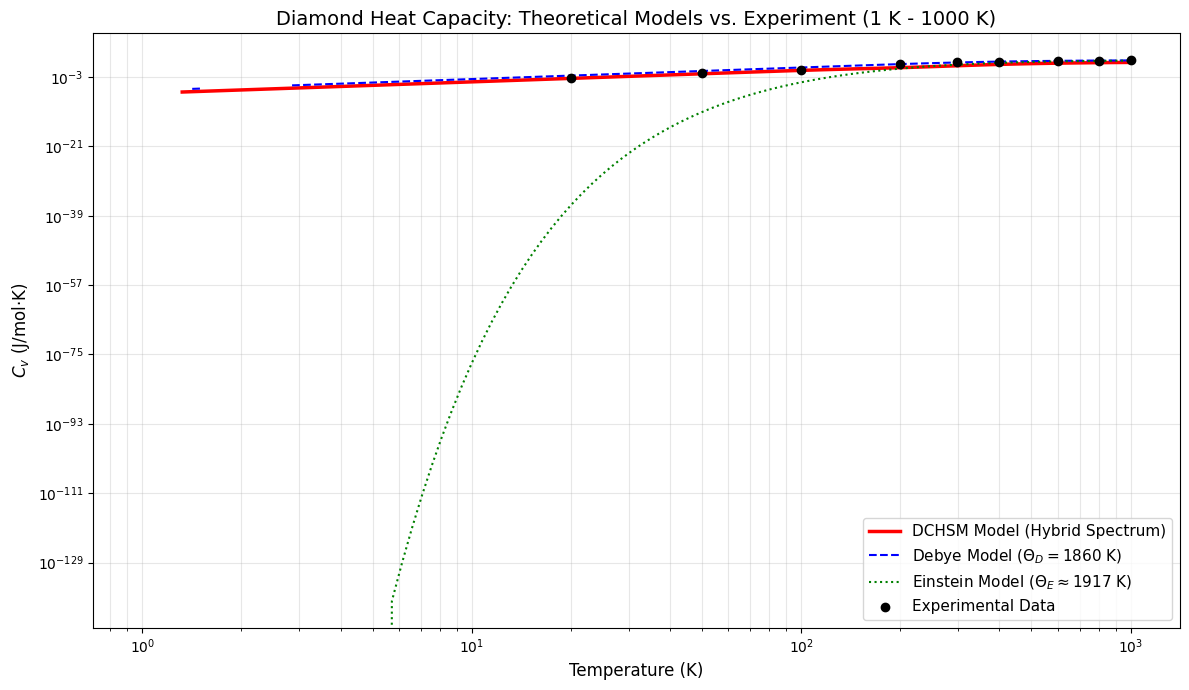

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Universal constants
R = 8.314462618          # J/(mol*K)
HBAR = 1.054571817e-34   # J*s
KB = 1.380649e-23        # J/K
C = 2.99792458e10        # speed of light in cm/s

# Convert wavenumber (cm^-1) to angular frequency (rad/s):
# omega = 2*pi*c*(cm^-1)
CM_TO_RAD = 2.0 * np.pi * C


class DiamondThermalModel:
    def __init__(self, frequencies=None, degeneracies=None):
        """
        frequencies: array of Raman / optical mode frequencies in cm^-1
        degeneracies: matching array of degeneracies
        """

        # Example placeholder spectrum so the code runs.
        # Replace with your actual 9 discrete frequencies and degeneracies.
        if frequencies is None:
            frequencies = np.array([1332.0], dtype=float)
        if degeneracies is None:
            degeneracies = np.array([45.0], dtype=float)

        self.frequencies = np.asarray(frequencies, dtype=float)
        self.degeneracies = np.asarray(degeneracies, dtype=float)

        if self.frequencies.ndim != 1 or self.degeneracies.ndim != 1:
            raise ValueError("frequencies and degeneracies must be 1D arrays")
        if len(self.frequencies) != len(self.degeneracies):
            raise ValueError("frequencies and degeneracies must have the same length")
        if np.any(self.frequencies <= 0):
            raise ValueError("all frequencies must be positive")
        if np.any(self.degeneracies < 0):
            raise ValueError("all degeneracies must be non-negative")

        self.total_discrete_modes = np.sum(self.degeneracies)

        # 16 atoms -> 48 vibrational DOF
        self.total_modes = 48.0

        # Residual acoustic continuum
        self.cutoff_freq = 621.0 * CM_TO_RAD   # rad/s
        self.acoustic_weight = 3.0             # remaining acoustic DOF

    def einstein_cv(self, T, freq_cm):
        """Einstein heat capacity for one mode frequency (cm^-1)."""
        if T <= 1e-12:
            return 0.0

        omega = freq_cm * CM_TO_RAD
        x = (HBAR * omega) / (KB * T)

        if x > 700:   # avoid overflow in exp
            return 0.0

        ex = np.exp(x)
        denom = ex - 1.0
        if denom == 0.0:
            return 0.0

        return R * (x**2 * ex) / (denom**2)

    @staticmethod
    def debye_integrand(x):
        if x > 700:
            return 0.0
        ex = np.exp(x)
        denom = ex - 1.0
        if denom == 0.0:
            return 0.0
        return (x**4 * ex) / (denom**2)

    def debye_cv(self, T, theta_d):
        """Debye heat capacity."""
        if T <= 1e-12:
            return 0.0

        x_max = theta_d / T
        integral, _ = quad(self.debye_integrand, 0.0, x_max, limit=300)
        return 9.0 * R * (T / theta_d) ** 3 * integral

    def residual_integrand(self, omega, T):
        """Acoustic continuum contribution integrand."""
        if T <= 1e-12:
            return 0.0

        x = (HBAR * omega) / (KB * T)
        if x > 700:
            return 0.0

        ex = np.exp(x)
        denom = ex - 1.0
        if denom == 0.0:
            return 0.0

        # Normalize DOS so ∫ g(omega) domega = acoustic_weight
        dos = (3.0 * self.acoustic_weight * omega**2) / (self.cutoff_freq**3)
        return dos * (x**2 * ex) / (denom**2)

    def dchsm_cv(self, T):
        """Discrete-Continuum Hybrid Spectral Model (DCHSM)."""
        if T <= 1e-12:
            return 0.0

        # 1) Discrete optical modes
        cv_discrete = 0.0
        for freq_cm, g in zip(self.frequencies, self.degeneracies):
            cv_discrete += (g / self.total_modes) * self.einstein_cv(T, freq_cm)

        # 2) Residual acoustic continuum
        integral, _ = quad(
            self.residual_integrand,
            0.0,
            self.cutoff_freq,
            args=(T,),
            limit=300
        )
        cv_residual = (R / self.total_modes) * integral

        return cv_discrete + cv_residual


# Simulation and plotting
model = DiamondThermalModel()

temp_range = np.logspace(0, 3, 100)  # 1 K to 1000 K

cv_dchsm = np.array([model.dchsm_cv(t) for t in temp_range])
cv_debye = np.array([model.debye_cv(t, 1860.0) for t in temp_range])          # theta_D in K
cv_einstein = np.array([3.0 * model.einstein_cv(t, 1332.0) for t in temp_range])

# Experimental data points
exp_t = np.array([20, 50, 100, 200, 298.15, 400, 600, 800, 1000], dtype=float)
exp_cv = np.array([0.00063, 0.012, 0.059, 2.15, 6.11, 10.23, 16.12, 19.50, 21.45], dtype=float)

plt.figure(figsize=(12, 7))
plt.loglog(temp_range, cv_dchsm, 'r-', label='DCHSM Model (Hybrid Spectrum)', linewidth=2.5)
plt.loglog(temp_range, cv_debye, 'b--', label=r'Debye Model ($\Theta_D = 1860$ K)')
plt.loglog(temp_range, cv_einstein, 'g:', label=r'Einstein Model ($\Theta_E \approx 1917$ K)')
plt.scatter(exp_t, exp_cv, color='black', label='Experimental Data', zorder=5)

plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel(r'$C_v$ (J/mol·K)', fontsize=12)
plt.title('Diamond Heat Capacity: Theoretical Models vs. Experiment (1 K - 1000 K)', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [2]:
def S_oms(f):
    """Optical metrology noise: (P pm / sqrt(Hz))^2 * [1 + (2mHz/f)^4]."""
    f = np.asarray(f, float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    """Acceleration noise: (A fm/s^2 / sqrt(Hz))^2 * shaping factors."""
    f = np.asarray(f, float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    """
    Appendix B Eq. (B.14):
      N~_{A,E} = 1/2 [2+cos(f/f*)] * S_oms/L^2
              + 2 [1+cos(f/f*)+cos^2(f/f*)] * S_acc/L^2 * (1/(2πf))^4
    """
    f = np.asarray(f, float)
    x = f / F_STAR
    cosx = np.cos(x)

    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    """
    Appendix B Eq. (B.15):
      N~_T = [1-cos(f/f*)] * S_oms/L^2
           + 2 [1-cos(f/f*)]^2 * S_acc/L^2 * (1/(2πf))^4
    """
    f = np.asarray(f, float)
    x = f / F_STAR
    one_minus_cos = 1.0 - np.cos(x)

    term_oms = one_minus_cos * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (one_minus_cos**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc


In [3]:
def gauss_legendre_sphere(lmax, n_theta=None, n_phi=None):
    """
    Quadrature on S^2 using Gauss–Legendre in mu=cos(theta) and uniform phi.
    Much lower spherical-harmonic leakage than Fibonacci sampling.

    Recommended:
      n_theta >= lmax+1
      n_phi   >= 2*lmax+1
    """
    if n_theta is None:
        n_theta = lmax + 6          # a bit conservative
    if n_phi is None:
        n_phi = 4*lmax + 2          # conservative for phi modes

    # Gauss–Legendre nodes/weights on mu in [-1,1]
    mu, w_mu = np.polynomial.legendre.leggauss(n_theta)  # mu=cos(theta)
    theta = np.arccos(np.clip(mu, -1.0, 1.0))

    # Uniform phi
    phi = np.linspace(0.0, 2.0*np.pi, n_phi, endpoint=False)
    dphi = 2.0*np.pi / n_phi

    # Mesh
    TH, PH = np.meshgrid(theta, phi, indexing="ij")  # (n_theta,n_phi)
    th = TH.ravel()
    ph = PH.ravel()

    # Unit vectors khat
    st = np.sin(th)
    khat = np.stack([st*np.cos(ph), st*np.sin(ph), np.cos(th)], axis=1)

    # Weights: integral dOmega = dphi * w_mu
    w = np.repeat(w_mu, n_phi) * dphi  # length n_theta*n_phi

    return khat, w, ph, th

In [4]:
def polarization_tensors_from_angles(phi, theta):
    """
    Build + and x polarization tensors using the standard (e_theta,e_phi) basis,
    given angles for each sky direction.
    """
    e_theta = np.stack([np.cos(theta)*np.cos(phi),
                        np.cos(theta)*np.sin(phi),
                        -np.sin(theta)], axis=1)
    e_phi = np.stack([-np.sin(phi),
                      np.cos(phi),
                      np.zeros_like(phi)], axis=1)

    e_plus  = e_theta[:,:,None]*e_theta[:,None,:] - e_phi[:,:,None]*e_phi[:,None,:]
    e_cross = e_theta[:,:,None]*e_phi[:,None,:]   + e_phi[:,:,None]*e_theta[:,None,:]
    return e_plus, e_cross

In [5]:
def fibonacci_sphere(n_points):
    """Nearly-uniform points on S^2 with equal weights."""
    i = np.arange(n_points)
    golden = (1.0 + np.sqrt(5.0)) / 2.0
    phi = (2.0*np.pi * i) / golden
    z = 1.0 - 2.0*(i + 0.5)/n_points
    r = np.sqrt(np.clip(1.0 - z*z, 0.0, 1.0))
    x = r*np.cos(phi)
    y = r*np.sin(phi)
    khat = np.stack([x, y, z], axis=1)
    w = 4.0*np.pi / n_points
    return khat, w

def polarization_tensors(khat):
    """
    Build + and x polarization tensors using the standard (e_theta,e_phi) basis.
    """
    x, y, z = khat[:,0], khat[:,1], khat[:,2]
    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.mod(np.arctan2(y, x), 2.0*np.pi)

    e_theta = np.stack([np.cos(theta)*np.cos(phi),
                        np.cos(theta)*np.sin(phi),
                        -np.sin(theta)], axis=1)
    e_phi = np.stack([-np.sin(phi),
                      np.cos(phi),
                      np.zeros_like(phi)], axis=1)

    # outer products
    e_plus  = e_theta[:,:,None]*e_theta[:,None,:] - e_phi[:,:,None]*e_phi[:,None,:]
    e_cross = e_theta[:,:,None]*e_phi[:,None,:]   + e_phi[:,:,None]*e_theta[:,None,:]
    return e_plus, e_cross, phi, theta

def g_pol(lhat, e_tensor):
    """g^A = 1/2 l^a l^b e^A_ab."""
    return 0.5 * np.einsum("i,j,nij->n", lhat, lhat, e_tensor)


In [6]:
def sinc(x):
    x = np.asarray(x)
    out = np.ones_like(x, dtype=np.complex128)
    small = np.abs(x) < 1e-10
    xs = x[~small]
    out[~small] = np.sin(xs) / xs
    return out

def M_transfer(u, mu):
    """
    Appendix A Eq. (A.2) written in terms of u = f/f_* = 2π f L / c.
    With f_* = 1/(2πL) (c=1 units), πLf = u/2.
    M = exp(i * (u/2)*(1+mu)) * sin((u/2)*(1+mu)) / ((u/2)*(1+mu)).
    """
    arg = 0.5 * u * (1.0 + mu)
    return np.exp(1j*arg) * sinc(arg)

def T_transfer(u, mu):
    """
    Appendix A Eq. (A.5) in u,mu form:
      T = exp(-i u) * M(u, -mu) + exp(-i u mu) * M(u, mu).
    """
    return np.exp(-1j*u) * M_transfer(u, -mu) + np.exp(-1j*u*mu) * M_transfer(u, mu)

def R_plus_cross(u, khat, e_plus, e_cross, lhat_a, lhat_b):
    """
    Build R^+ and R^x for one Michelson-like combination at a vertex
    using two arms lhat_a, lhat_b (Appendix A Eq. (A.4)).
    """
    mu_a = khat @ lhat_a
    mu_b = khat @ lhat_b

    gpa = g_pol(lhat_a, e_plus)
    gxa = g_pol(lhat_a, e_cross)
    gpb = g_pol(lhat_b, e_plus)
    gxb = g_pol(lhat_b, e_cross)

    Ta = T_transfer(u, mu_a)
    Tb = T_transfer(u, mu_b)

    Rp = gpa*Ta - gpb*Tb
    Rx = gxa*Ta - gxb*Tb
    return Rp, Rx


In [7]:
import numpy as np
import healpy as hp

def healpix_sky(nside, nest=False):
    """Return khat (npix,3), theta, phi for HEALPix grid."""
    npix = hp.nside2npix(nside)
    ipix = np.arange(npix)
    theta, phi = hp.pix2ang(nside, ipix, nest=nest)
    khat = np.array(hp.ang2vec(theta, phi))  # (npix,3)
    return khat, theta, phi

def map2alm_complex_std(map_complex, lmax, iter=0):
    """
    Standard HEALPy convention:
      a_lm = ∫ map * Y_lm^* dΩ
    Works for complex map via real+imag split.
    """
    alm_re = hp.map2alm(np.real(map_complex), lmax=lmax, iter=iter)
    alm_im = hp.map2alm(np.imag(map_complex), lmax=lmax, iter=iter)
    return alm_re + 1j * alm_im

def map2alm_complex_Y(map_complex, lmax, iter=0):
    """
    Your notebook convention (matches scipy sph_harm without conjugation in the dot-product):
      c_lm = ∫ map * Y_lm dΩ

    For m>=0:
      c_lm = conj( ∫ conj(map) * Y_lm^* dΩ ) = conj( map2alm(conj(map)) )

    Returns HEALPy-packed alm for m>=0 with this convention.
    """
    return np.conj(map2alm_complex_std(np.conj(map_complex), lmax=lmax, iter=iter))

def alm_get(alm, lmax, ell, m):
    """Fetch packed alm coefficient for ell, m (m>=0 only)."""
    return alm[hp.Alm.getidx(lmax, ell, m)]

def coeff_full_m_from_maps(alms_posY, alms_std, lmax, ell, m):
    """
    Return coefficient c_{ell m} = ∫ map * Y_{ell m} dΩ for any m in [-ell..ell].

    Inputs:
      alms_posY: packed alm (m>=0) for ∫ map Y_lm dΩ
      alms_std : packed alm (m>=0) for ∫ map Y_lm^* dΩ

    For m>=0: use alms_posY.
    For m<0 : use Y_{l,-m} = (-1)^m conj(Y_{l,m}) => c_{l,-m} = (-1)^m * a_std(l,m)
    """
    if m >= 0:
        return alm_get(alms_posY, lmax, ell, m)
    mp = -m
    return ((-1)**mp) * alm_get(alms_std, lmax, ell, mp)

In [8]:
def deconvolve_pixwin_alm(alm, nside, lmax):
    """
    Divide a_{lm} by the HEALPix pixel window p_l (for l<=lmax).
    Safe and stable for small lmax like 10.
    """
    pw = hp.pixwin(nside, lmax=lmax)  # length lmax+1
    alm2 = alm.copy()
    for ell in range(lmax + 1):
        p = pw[ell]
        if p == 0:
            continue
        # divide all m=0..ell coefficients at this ell
        for m in range(ell + 1):
            idx = hp.Alm.getidx(lmax, ell, m)
            alm2[idx] /= p
    return alm2

In [9]:
# A,E,T mixing matrix (Eq. 4.25)
C_AET = np.array([
    [-1/np.sqrt(2),  0.0,          1/np.sqrt(2)],  # A
    [ 1/np.sqrt(6), -2/np.sqrt(6), 1/np.sqrt(6)],  # E
    [ 1/np.sqrt(3),  1/np.sqrt(3), 1/np.sqrt(3)],  # T
], dtype=float)
O_list = ["A", "E", "T"]
O_idx = {O:i for i,O in enumerate(O_list)}

def omega_channel_channel(f, Rtilde, Ntilde_O, Ntilde_Op):
    """
    Eq. (4.42): Omega^ell_{GW,OO',n}(f) h^2
    """
    pref = (4.0*np.pi**2 * np.sqrt(4.0*np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) * (np.sqrt(Ntilde_O*Ntilde_Op) / Rtilde)

def optimal_omega_from_pairs(omega_pairs):
    """
    Eq. (4.43) as written: sum over ordered pairs (O,O').
    omega_pairs is list/iterable of arrays Omega_{OO'}(f) for all ordered pairs.
    """
    inv2 = np.zeros_like(omega_pairs[0], dtype=float)
    for om in omega_pairs:
        inv2 += 1.0 / (om*om)
    return 1.0 / np.sqrt(inv2)

def build_Ymat(lmax, phi, theta):
    """Ymat[p, k] with k indexing (ell,m)."""
    lm_list = []
    cols = []
    for ell in range(lmax+1):
        for m in range(-ell, ell+1):
            lm_list.append((ell, m))
            cols.append(sph_harm(m, ell, phi, theta))
    Ymat = np.stack(cols, axis=1)
    idx_by_ell = {ell: [k for k,(e,m) in enumerate(lm_list) if e==ell] for ell in range(lmax+1)}
    return Ymat, lm_list, idx_by_ell

def reproduce_figure9_healpy(f_grid, lmax=10, nside=64, nest=False, iter_alm=0):
    """
    HEALPy implementation of your Figure-9 pipeline.

    Returns dict: ell -> Omega^ell_{GW,n}(f) h^2 / sqrt(4π)
    using your Eq. (4.42)/(4.43) code and A/E/T mixing.

    Notes:
      - nside must satisfy lmax <= 3*nside-1 (HEALPy limit). nside=64 is plenty for lmax=10.
      - Uses your integral convention c_lm = ∫ map * Y_lm dΩ (matches your scipy sph_harm dot-product).
      - Avoids explicit Y-matrix construction; uses healpy.map2alm.
    """
    f_grid = np.asarray(f_grid, float)

    # ---- Geometry: equilateral triangle in xy plane (your exact setup)
    L = L_ARM
    r1 = np.array([0.0, 0.0, 0.0])
    r2 = np.array([L,   0.0, 0.0])
    r3 = np.array([0.5*L, 0.5*np.sqrt(3.0)*L, 0.0])
    pos = [r1, r2, r3]

    def unit(v):
        return v / np.linalg.norm(v)

    l12 = unit(r2-r1); l13 = unit(r3-r1)
    l21 = unit(r1-r2); l23 = unit(r3-r2)
    l31 = unit(r1-r3); l32 = unit(r2-r3)

    arms_by_sc = {
        0: (l12, l13),
        1: (l23, l21),
        2: (l31, l32),
    }

    pos_sec = [p / C_LIGHT for p in pos]
    delta_sec = np.zeros((3,3,3))
    for i in range(3):
        for j in range(3):
            delta_sec[i,j] = pos_sec[i] - pos_sec[j]

    # ---- HEALPix sky
    khat, theta, phi = healpix_sky(nside, nest=nest)
    npix = khat.shape[0]

    # Your polarization basis (reuse your existing function)
    e_plus, e_cross = polarization_tensors_from_angles(phi, theta)

    # Precompute k·Δx for all ij and pixels
    kdot_delta = np.zeros((3,3,npix), dtype=float)
    for i in range(3):
        for j in range(3):
            kdot_delta[i,j,:] = khat @ delta_sec[i,j]

    # ---- tilde-noise arrays (your existing functions)
    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}

    # Fig. 9 rescaling
    Y00 = 1.0 / np.sqrt(4.0*np.pi)

    # output
    omega_by_ell = {ell: np.zeros_like(f_grid) for ell in range(lmax+1)}

    # main frequency loop
    for fi, f in enumerate(f_grid):
        u = f / F_STAR

        # R_i^A(k) for each spacecraft i and pol
        Rplus  = np.zeros((3, npix), dtype=np.complex128)
        Rcross = np.zeros((3, npix), dtype=np.complex128)
        for i in range(3):
            la, lb = arms_by_sc[i]
            Rp, Rx = R_plus_cross(u, khat, e_plus, e_cross, la, lb)
            Rplus[i]  = Rp
            Rcross[i] = Rx

        # Σ_A R_i^A R_j^{A*}
        pol_sum = (Rplus[:,None,:]*np.conj(Rplus[None,:,:]) +
                   Rcross[:,None,:]*np.conj(Rcross[None,:,:]))

        # phase factor exp(-2π i f k·Δx)
        phase = np.exp(-2j*np.pi*f * kdot_delta)

        # Build 9 HEALPix maps M_ij(k) = (1/(8π)) pol_sum_ij(k) * phase_ij(k)
        # (This exactly matches your previous integral that used weight_factor = w/(8π).)
        maps = np.zeros((3,3,npix), dtype=np.complex128)
        maps[:] = (pol_sum * phase) / (8.0*np.pi)

        # For each (i,j), compute:
        #   alms_posY : c_lm (m>=0) for ∫ map * Y_lm dΩ   (your convention)
        #   alms_std  : a_lm (m>=0) for ∫ map * Y_lm^* dΩ (HEALPy standard)
        lmax_eff = lmax
        alms_posY = [[None]*3 for _ in range(3)]
        alms_std  = [[None]*3 for _ in range(3)]
        for i in range(3):
            for j in range(3):
                alms_posY[i][j] = map2alm_complex_Y(maps[i,j], lmax=lmax_eff, iter=iter_alm)
                alms_std[i][j]  = map2alm_complex_std(maps[i,j], lmax=lmax_eff, iter=iter_alm)

                alms_posY[i][j] = deconvolve_pixwin_alm(alms_posY[i][j], nside=nside, lmax=lmax_eff)
                alms_std[i][j]  = deconvolve_pixwin_alm(alms_std[i][j],  nside=nside, lmax=lmax_eff)

        # Now compute Rtilde^ell_{OO'}(f) using FULL m = -ell..ell coefficients
        for ell in range(lmax+1):
            Z = {}

            for O in O_list:
                for Op in O_list:
                    cO  = C_AET[O_idx[O]]
                    cOp = C_AET[O_idx[Op]]

                    # sum over m: | z_m |^2 where z_m = Σ_ij cOi cOpj R_ij^{ell m}
                    s = 0.0
                    for m in range(-ell, ell+1):
                        # build mixed coefficient at this (ell,m)
                        z = 0.0 + 0.0j
                        for i in range(3):
                            for j in range(3):
                                Rij = coeff_full_m_from_maps(
                                    alms_posY[i][j], alms_std[i][j], lmax_eff, ell, m
                                )
                                z += 2 * cO[i] * cOp[j] * Rij
                        s += np.abs(z)**2

                    Rtilde = np.sqrt(s)
                    Z[(O,Op)] = Rtilde

            # Eq. (4.42) per ordered pair, Eq. (4.43) combine
            omega_pairs = []
            for O in O_list:
                for Op in O_list:
                    Rtilde = Z[(O,Op)]
                    omega_pairs.append(
                        omega_channel_channel(f, Rtilde, N_map[O][fi], N_map[Op][fi])
                    )

            omega_by_ell[ell][fi] = optimal_omega_from_pairs(omega_pairs) * Y00

    return omega_by_ell

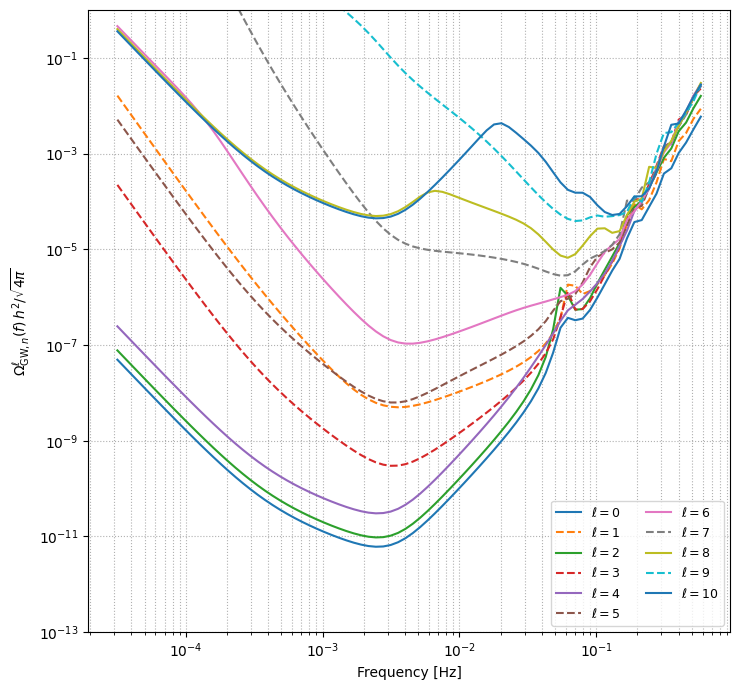

In [38]:
f = np.logspace(-4.5, -0.235, 80)
curves = reproduce_figure9_healpy(f, lmax=10, nside=64, iter_alm=2)


plt.figure(figsize=(7.5, 7))

for ell in range(0, 11):
    ls = "-" if (ell % 2 == 0) else "--"  # even solid, odd dashed (paper caption)
    plt.loglog(f, curves[ell], linestyle=ls, label=fr"$\ell={ell}$")

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 / \sqrt{4\pi}$")
plt.ylim(1e-13, 1e0)
plt.grid(True, which="both", linestyle=":")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [39]:
import numpy as np
import pandas as pd

def snr_table_eq444(
    f_grid,
    omega_sens_by_ell,      # dict ell -> Omega_{GW,n}^ell(f) h^2  (or plotted version, see flag)
    OmegaGW_h2,             # callable f->OmegaGW(f)h^2 OR array on f_grid
    Tobs_yr=4.0,
    Cl_GW=None,             # C_ell^{GW} from Eq (2.9); dict or array; if None -> C_ell=1
    curves_are_divided_by_sqrt4pi=True,  # True if your curves are the Fig.9 plotted ones
    fmin=None, fmax=None,   # optional band limits
):
    """
    Implements Eq. (4.44) specialized using Eqs. (4.42)-(4.43) and the definition
    Omega_GW^ell = sqrt(C_ell^{GW}) Omega_GW, cf. Eq. (5.1).

    SNR_ell^2 = Tobs * ∫ df ( Omega_GW^ell(f) h^2 / Omega_{GW,n}^ell(f) h^2 )^2
    """
    f = np.asarray(f_grid, dtype=float)
    if np.any(np.diff(f) <= 0):
        raise ValueError("f_grid must be strictly increasing.")

    # band mask
    band = np.ones_like(f, dtype=bool)
    if fmin is not None:
        band &= (f >= float(fmin))
    if fmax is not None:
        band &= (f <= float(fmax))
    if band.sum() < 2:
        raise ValueError("Frequency band has fewer than 2 points.")

    # Evaluate Omega_GW(f) h^2 on the same grid
    if callable(OmegaGW_h2):
        OmegaGW_vals = np.asarray(OmegaGW_h2(f), dtype=float)
    else:
        OmegaGW_vals = np.asarray(OmegaGW_h2, dtype=float)
        if OmegaGW_vals.shape != f.shape:
            raise ValueError("If OmegaGW_h2 is an array, it must have the same shape as f_grid.")

    # observation time in seconds
    Tobs_sec = float(Tobs_yr * 365.25 * 24.0 * 3600.0)

    rows = []
    for ell in sorted(omega_sens_by_ell.keys()):

        omega_sens = np.asarray(omega_sens_by_ell[ell], dtype=float)

        # Undo the Fig.9 plotting rescale if needed: plotted is Omega_{GW,n}^ell h^2 / sqrt(4π)
        if curves_are_divided_by_sqrt4pi:
            omega_sens = omega_sens * np.sqrt(4.0 * np.pi)

        # Get C_ell^{GW} (Eq. 2.9)
        if Cl_GW is None:
            C_l = 1.0
        elif isinstance(Cl_GW, dict):
            C_l = float(Cl_GW.get(ell, 0.0))
        else:
            C_l = float(Cl_GW[ell])

        # Omega_GW^ell(f) h^2 = sqrt(C_ell^{GW}) Omega_GW(f) h^2  (Eq. 5.1; “following Eq. 4.44”)
        Omega_lGW = np.sqrt(max(C_l, 0.0)) * OmegaGW_vals

        # valid mask
        mask = band & np.isfinite(omega_sens) & (omega_sens > 0) & np.isfinite(Omega_lGW)

        if np.count_nonzero(mask) < 2:
            snr2 = 0.0
        else:
            integrand = (Omega_lGW[mask] / omega_sens[mask])**2
            snr2 = float(Tobs_sec * np.trapz(integrand, f[mask]))

        rows.append({"ell": ell, "snr2": snr2, "snr": float(np.sqrt(snr2))})

    return pd.DataFrame(rows).set_index("ell")

In [40]:
# 1) sensitivity curves (your dict ell -> curve)
omega_ell = curves

# 2) example isotropic SGWB spectrum Omega_GW(f) h^2
Omega0 = 1e-12
OmegaGW_h2 = lambda f: Omega0 * np.ones_like(f)

# 3) choose C_ell^{GW}; if you don't have a model yet, set C_ell=1 (means "unit anisotropy amplitude")
df = snr_table_eq444(
    f_grid=f,
    omega_sens_by_ell=omega_ell,
    OmegaGW_h2=OmegaGW_h2,
    Tobs_yr=4.0,
    Cl_GW=None,  # or e.g. {0:1.0, 1:1e-6, 2:1e-6, ...}
    curves_are_divided_by_sqrt4pi=True,  # set False if you already stored unscaled curves
)

display(df)

,snr2,snr
ell,,
0,7.474196e+02,27.338976
1,2.500219e-03,0.050002
2,3.046335e+02,17.453752
3,4.055275e-01,0.636810
4,2.998141e+01,5.475528
5,1.063261e-03,0.032608
6,6.833947e-06,0.002614
7,6.084466e-08,0.000247
8,7.735143e-09,0.000088
